In [26]:
import cartopy.crs as ccrs
import healpix as hp
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [27]:
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['UK']

In [28]:
ds = cat['um_Africa_km4p4_RAL3P3_n1280_GAL9_nest'](zoom=9, time='PT1H').to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<Figure size 640x480 with 0 Axes>

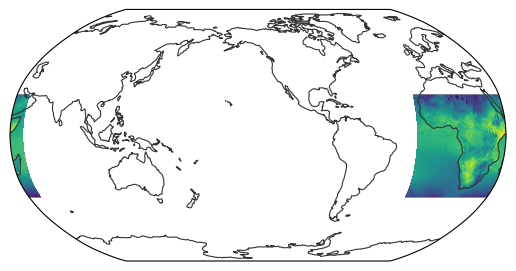

In [29]:
egh.healpix_show(ds.tas.isel(time=10))

In [31]:
ds.attrs

{'Met Office DYAMOND3 simulations': 'A group of experiments have been conducted using the Met Office Unified Model (MetUM) with a focus on the DYAMOND-3 period (Jan 2020-Feb 2021). While this experiments include standalone explicit convection global simulations we have also developed a cyclic tropical channel and include limited area model simulations to build our understanding of how resolving smaller-scale processes feeds back on to the large-scale atmospheric circulation.',
 'bounds': {'lower_left_lat': -40.0,
  'lower_left_lon': 340.0,
  'upper_right_lat': 25.959999084472656,
  'upper_right_lon': 53.959999084472656},
 'latitiude_convention': '[-90, 90]',
 'longitude_convention': '[0, 360]',
 'regional': True,
 'simulation': 'Africa_km4p4_RAL3P3.n1280_GAL9_nest'}

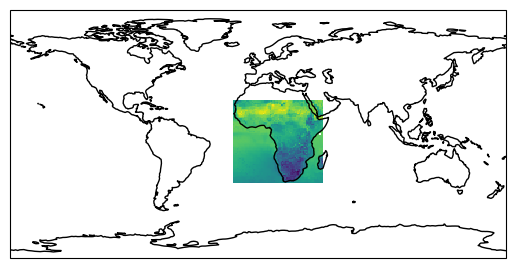

In [51]:
# Find the HEALPix pixels that are closest to the 1x1 degree grid points.
lon = np.arange(-18, 48, 1)
lat = np.arange(-35, 25, 1)
pix = xr.DataArray(
    hp.ang2pix(ds.crs.healpix_nside, *np.meshgrid(lon, lat), nest=True, lonlat=True),
    coords=(("lat", lat), ("lon", lon)),
)

# Plot the 1x1 world map for a given variable and time.
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ds_ll = ds.tas.sel(cell=pix, method='nearest').sel(time="2020-05-30 00:00")

ax.set_global()
ax.pcolormesh(ds_ll.lon, ds_ll.lat, ds_ll)
ax.coastlines()

In [14]:
ds.cell

<xarray.DataArray 'cell' (cell: 1572864)> Size: 13MB
array([      0,       1,       2, ..., 3145725, 3145726, 3145727])
Coordinates:
  * cell     (cell) int64 13MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    crs      float64 8B ...

In [20]:
ds = ds.pipe(egh.attach_coords)

In [24]:
ds.lat.min()

<xarray.DataArray 'lat' ()> Size: 8B
array(-89.90862927)
Coordinates:
    crs      int64 8B 0